# Image data: Inference on Spatial Data and Parameters

*Authors:  Valentin Pratz and Niels Bracher*

In this tutorial, we demonstrate how to use BayesFlow with spatial (i.e., image) data. We will demonstrate two common scnearios:

- Inferring low-dimensional parameters from high-dimensional images
- Generating high-dimensional images given low-dimensional parameters

The main challenge when analyzing image data is building suitable backbone networks. The devil lies in the detail.

Lucikly, we can leverage common architectures used in image processing that are readily available in BayesFlow.

In [1]:
import bayesflow as bf
import keras
import matplotlib.pyplot as plt
import numpy as np

# reduce image resolution to reduce file size
plt.rcParams["figure.dpi"] = 80

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:2026-03-06 14:59:47,898:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## Inference on Spatial Data: Inferring the Parameters of Gaussian Random Fields

As an example, we will take a look at Gaussian random fields (GRFs).
For a nice introduction that also serves as the inspiration for the example below, refer to the article [The Beauty of Gaussian Random Fields](https://structures.uni-heidelberg.de/blog/posts/gaussian-random-fields/index.php) ([archive](https://web.archive.org/web/20250323141017/https://structures.uni-heidelberg.de/blog/posts/gaussian-random-fields/index.php)) by Sara Konrad. Below, we give a short summary that should be sufficient to get the gist of the example.

GRFs describe spatially correlated variables.
For homogeneous and isotropic GRFs, the underlying covariance function does not depend on the position and only depends on the distance, not on the direction.
In that case, the GRF can be completely described by a mean value, which can be set to zero without loss of generality, and the covariance function.
The covariance function can be translated into frequency space using the Fourier transform, giving the *power spectrum* of the covariance function.
This describes the amount of correlation as a function of the wave number $k$.
An interesting example is the power law power spectrum $P(k)=k^{-\alpha}$.
It shows the same behavior on different scales, leading to fractal structures.
The exact behavior is defined by the exponent $\alpha$, which we want to estimate, along with a scaling factor describing the magnitude of the field.

For the simulations, we will use the [FyeldGenerator](https://github.com/cphyc/FyeldGenerator) package ([Zenodo](https://zenodo.org/record/7427712)).

In [2]:
try:
    from FyeldGenerator import generate_field
except ImportError:
    import pip
    pip.main(['install', 'FyeldGenerator'])
    from FyeldGenerator import generate_field

The package provides us with the `generate_field` function, which requires a distribution to sample complex values (usually from a standard normal distribution for both real and imaginary part), a power spectrum and the shape of the desired grid. Let's define them and take a look at some examples:

In [3]:
def generate_power_spectrum(alpha, scale):
    def power_spectrum(k):
        return np.power(k, -alpha) * scale**2

    return power_spectrum


def distribution(shape):
    a = np.random.normal(loc=0, scale=np.sqrt(np.prod(shape)), size=shape)
    b = np.random.normal(loc=0, scale=np.sqrt(np.prod(shape)), size=shape)
    return a + 1j * b

In [4]:
power_spectrum = generate_power_spectrum(3.0, 1.0)

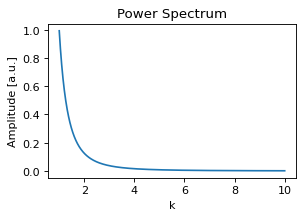

In [5]:
plt.figure(figsize=(4,2.5))
k = np.logspace(0.001, 1, 300)
plt.plot(k, power_spectrum(k))
plt.title("Power Spectrum")
plt.xlabel("k")
plt.ylabel("Amplitude [a.u.]");

Generating a field is internally achieved by sampling random numbers, a few multiplications and a fast Fourier transform, so generating a field is very fast:

In [6]:
%%time
np.random.seed(2025)
field_shape = (64, 64)
field = generate_field(distribution, power_spectrum, field_shape)

CPU times: user 798 μs, sys: 47 μs, total: 845 μs
Wall time: 733 μs


Below, we take a look at the way the patterns change when we change $\alpha$.

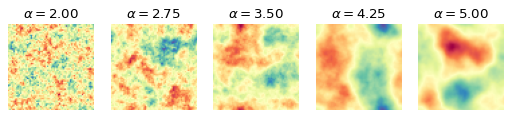

In [7]:
n_examples = 5
alphas = np.linspace(2, 5, n_examples)
log_std = 0
cmap = "Spectral"

fig, axs = plt.subplots(1, n_examples, figsize=(n_examples * 1.6, 1.7))
for alpha, ax in zip(alphas, axs):
    power_spectrum = generate_power_spectrum(alpha, np.exp(log_std))
    field = generate_field(distribution, power_spectrum, field_shape)
    max_magnitude = np.max(np.abs(field))
    ax.imshow(field, cmap=cmap, vmin=-max_magnitude, vmax=max_magnitude)
    ax.set_title(f"$\\alpha={alpha:.2f}$")
    ax.set_axis_off()

The difference is clearly visible, as the structures become more homogeneous as $\alpha$ increases.
The task is now for the summary network to learn relevant summary statistics from the images that enable the inference model to determine the correct parameter values.

### Simulator

We define a simple prior for the parameters and wrap the `generate_field` function to generate data in the desired structure.

In [8]:
rng = np.random.default_rng()


def prior():
    return {"log_std": rng.normal(), "alpha": rng.normal(loc=4, scale=0.5)}


def likelihood(log_std, alpha, field_shape=(64, 64)):
    field = generate_field(
        distribution, generate_power_spectrum(alpha, np.exp(log_std)), field_shape
    )

    return {"field": field[..., None]}

simulator = bf.make_simulator([prior, likelihood])

We can quickly check that the output shapes of the simulator match our expectations:

In [9]:
keras.tree.map_structure(keras.ops.shape, simulator.sample(3))

{'log_std': (3, 1), 'alpha': (3, 1), 'field': (3, 64, 64, 1)}

### Summary Network

As we have translation-invariant images, [convolutional neural networks (CNNs)](https://en.wikipedia.org/wiki/Convolutional_neural_network) are a natural choice as summary networks.
We currently provide the `ResNet` class in our experimental module, which implements a CNN architecture.
Each residual layer produces an output which divides the side length of the image by two.
The `widths` argument describes the number of *channels* the layer produces.
The `ResNet` does not handle to post-processing of the outputs, which consists of flattening and an additional dense layer, followed by a projection to the desired number of summary dimensions. In the class below, we inherit from `SummaryNetwork` and perform those steps, making the `ResNet` usable as a summary network.

In [10]:
summary_network = bf.networks.ConvolutionalNetwork(
    summary_dim=6,
    widths=[8, 16, 32, 64],
    blocks_per_stage=1,
    down_mode="max_pool",
    pool_head="flatten",
    norm="group",
    groups=1,
)

### Training

We will use online training, i.e., simulate the training data on the fly, but we already generate the validation data and test data:

In [11]:
%%time
validation_data = simulator.sample(100)

CPU times: user 23.3 ms, sys: 1.02 ms, total: 24.3 ms
Wall time: 24 ms


In [12]:
%%time
test_data = simulator.sample(1000)

CPU times: user 209 ms, sys: 16 ms, total: 225 ms
Wall time: 224 ms


We now create the workflow object we use for training.

In [13]:
workflow = bf.workflows.BasicWorkflow(
    simulator=simulator,
    summary_network=summary_network,
    inference_network="coupling_flow",
    inference_variables=["log_std", "alpha"],
    summary_variables=["field"],
    standardize="all",
)

Now we are ready to start the online training.
For better results, try to increase the number of epochs.

As we use convolutional layers, training can be quite slow on a CPU (10-15 minutes for 10 epochs), and using a GPU can significantly speed up training (< 1 minute).

In [14]:
history = workflow.fit_online(
    num_batches_per_epoch=1000,
    validation_data=validation_data,
    batch_size=32,
    epochs=20,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 1.2952 - val_loss: 0.4309
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: -0.0155 - val_loss: -0.8197
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -0.6972 - val_loss: -0.8724
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -0.9603 - val_loss: -0.7752
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -1.1919 - val_loss: -1.4253
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -1.3859 - val_loss: -1.5261
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -1.5249 - val_loss: -1.7041
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -1.6135 - val_loss: -1.8653
Epoch 9/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -1.6924 - val_loss: -1.8909
Epoch 10/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -1.8107 - val_loss: -1.6321
Epoch 11/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: -1.9113 - val_loss: -2.2524
Epoch 

INFO:bayesflow:Training completed in 3.48 minutes.


### Evaluation

Finally, we can plot the diagnostics. They show good recovery and calibration, indicating successful training.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

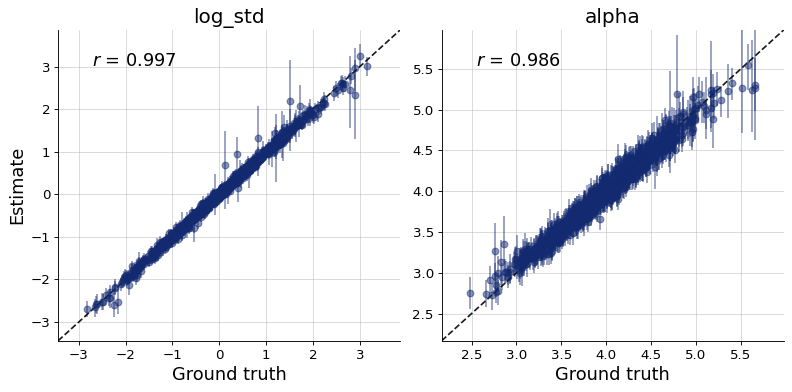

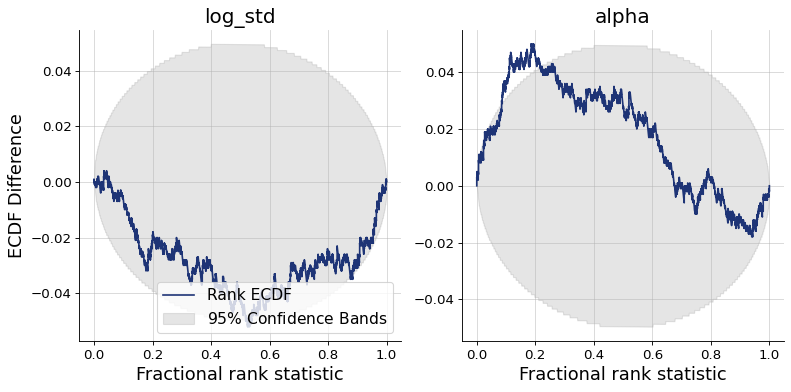

In [15]:
figs = workflow.plot_custom_diagnostics(
    test_data=test_data,
    plot_fns={
        "recovery": bf.diagnostics.recovery,
        "calibration": bf.diagnostics.calibration_ecdf,
    },
)

## Inference of Spatial Parameters: Generating Gaussian Random Fields

In the following we will turn the task around: create fields given the field parameters.

### Simulator

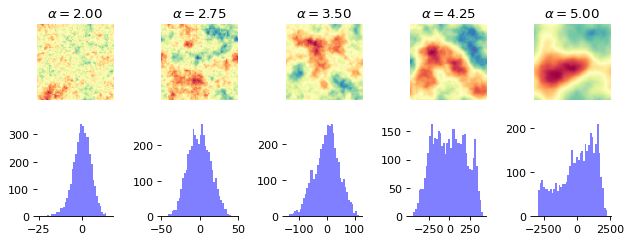

In [16]:
fig, axs = plt.subplots(2, n_examples, figsize=(n_examples * 1.6, 1.9*1.7))
for a, alpha in enumerate(alphas):
    power_spectrum = generate_power_spectrum(alpha, np.exp(log_std))
    field = generate_field(distribution, power_spectrum, field_shape)
    max_magnitude = np.max(np.abs(field))
    axs[0, a].imshow(field, cmap=cmap, vmin=-max_magnitude, vmax=max_magnitude)
    axs[0, a].set_title(f"$\\alpha={alpha:.2f}$")
    axs[0, a].set_axis_off()

    axs[1, a].hist(field.flatten(), bins=40, color="blue", alpha=0.5)
    axs[1, a].spines[["left", "right", "top"]].set_visible(False)

plt.tight_layout()

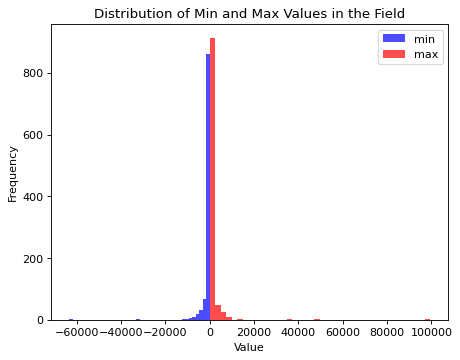

In [17]:
samples = simulator.sample(1000)
plt.figure()
plt.hist(samples["field"].min(axis=(1, 2)).flatten(), bins=40, color="blue", alpha=0.7)
plt.hist(samples["field"].max(axis=(1, 2)).flatten(), bins=40, color="red", alpha=0.7)
plt.legend(["min", "max"])
plt.title("Distribution of Min and Max Values in the Field")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Field values span an extreme range with the current definition of the simulator. The learnable standardization preprocessing of BayesFlow would still allow to proceede from here. Though, given that we are interested in the structure certain parameter values generate, we will modify the simulator by adjusting the field length scale to a given $\alpha$ value dynamically. This leads to a more similar field value range for the prior over $\alpha$ values but does not change the underlying structure of the fields.

In [18]:
rng = np.random.default_rng(seed=42)

def distribution(shape):
    a = rng.normal(loc=0, scale=1., size=shape)
    b = rng.normal(loc=0, scale=1., size=shape)
    return a + 1j * b

def prior():
    log_std = rng.normal(scale=0.3)
    alpha = rng.normal(loc=3, scale=0.5)
    params_expanded = np.array([log_std, alpha])
    params_expanded = np.ones(field_shape + (2,)) * params_expanded[None, None, :]
    return {
        "log_std": log_std,
        "alpha": alpha,
        "params_expanded": params_expanded
    }

def likelihood(log_std, alpha, field_shape=(64, 64)):
    field = generate_field(
        distribution, generate_power_spectrum(alpha, np.exp(log_std)), field_shape, unit_length=1/(np.abs(alpha) + 1e-7)
    )

    return {"field": field[..., None]}

simulator = bf.make_simulator([prior, likelihood])

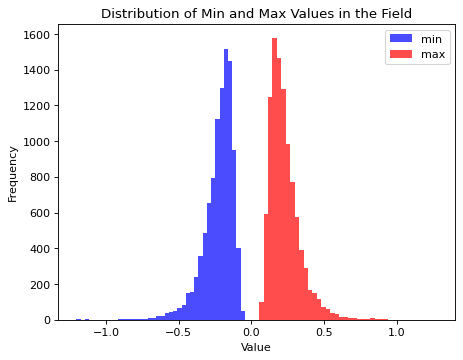

In [19]:
samples = simulator.sample(10000)
plt.figure()
plt.hist(samples["field"].min(axis=(1, 2)).flatten(), bins=40, color="blue", alpha=0.7)
plt.hist(samples["field"].max(axis=(1, 2)).flatten(), bins=40, color="red", alpha=0.7)
plt.legend(["min", "max"])
plt.title("Distribution of Min and Max Values in the Field")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### Inference Network
For the inference network we can pick one from the following configurations (feel free to explore them all):

In [20]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .rename("params_expanded", "inference_conditions")
    .rename("field", "inference_variables")
)

configs = {
    "UNet": {
        "widths": (64, 128, 256, 512),
        "res_blocks": 2,
        "attn_stage": None,
    },
    "UViT": {
        "widths": (64, 128, 256),
        "res_blocks": 3,
        "transformer_blocks": 2,
        "transformer_dropout": 0.2,
        "transformer_width": 512,
    },
    "ResidualUViT": {
        "widths": (64, 128, 256),
        "res_blocks_up": 2,
        "res_blocks_down": 3,
        "transformer_blocks": 2,
        "transformer_dropout": 0.2,
        "transformer_width": 512,
    }
}

### Training

The code below will be very slow on CPU. You definitely need a GPU if you are interested in image generation. Below, we demonstrate training with the `ResdiualUViT` architecture as backbone of a diffusion model.

In [21]:
diffusion = bf.networks.DiffusionModel(
    subnet=bf.networks.ResidualUViT,
    subnet_kwargs=configs["ResidualUViT"],
    prediction_type="velocity",
    noise_schedule="cosine",
)

workflow = bf.workflows.BasicWorkflow(
    simulator=simulator,
    inference_network=diffusion,
    adapter=adapter,
    standardize="inference_conditions",
    initial_learning_rate=1e-4,
)

In [22]:
history = workflow.fit_online(
    epochs=20,
    batch_size=32,
    num_batches_per_epoch=1000,
    validation_data=100
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - loss: 0.0487 - val_loss: 0.0216
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0175 - val_loss: 0.0189
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0173 - val_loss: 0.0204
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0168 - val_loss: 0.0165
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0166 - val_loss: 0.0202
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0168 - val_loss: 0.0151
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0164 - val_loss: 0.0177
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0172 - val_loss: 0.0173
Epoch 9/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0162 - val_loss: 0.0140
Epoch 10/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0165 - val_loss: 0.0161
Epoch 11/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 0.0165 - val_loss: 0.0169
Epoch 12

INFO:bayesflow:Training completed in 9.69 minutes.


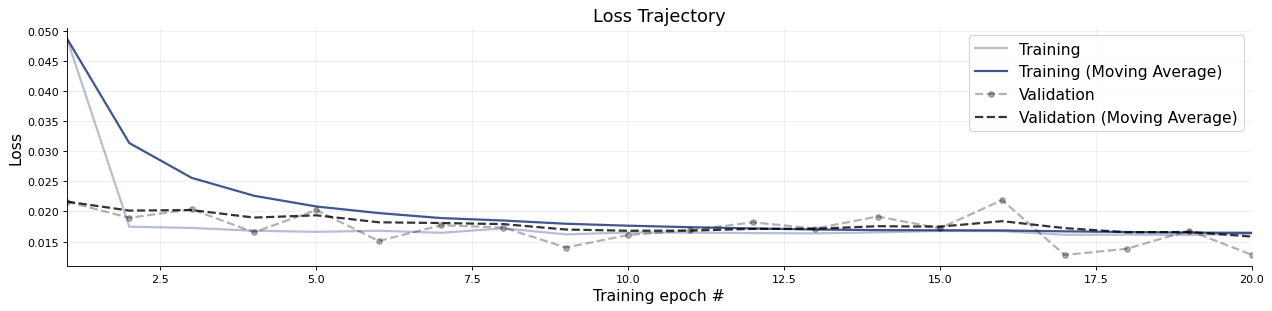

In [23]:
f = bf.diagnostics.plots.loss(history)

### Evaluation

We can briefly take a look at a few test images and corresponding generated images:

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 14.12 seconds.


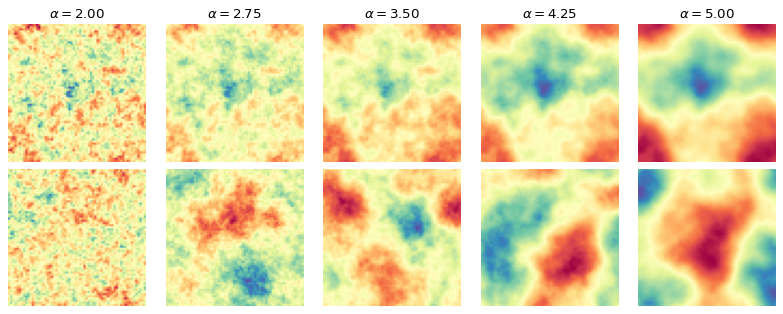

In [24]:
def plot_distribution(shape):
    rng = np.random.default_rng(seed=1234123)
    a = rng.normal(loc=0, scale=1., size=shape)
    b = rng.normal(loc=0, scale=1., size=shape)
    return a + 1j * b

simulator_spectra = [generate_power_spectrum(alpha, np.exp(log_std)) for alpha in alphas]
fields_simulated = np.stack([generate_field(plot_distribution, spectra, field_shape, unit_length=1/(np.abs(alpha) + 1e-7)) for (alpha, spectra) in zip(alphas, simulator_spectra)], axis=0)
params_expanded = []
for alpha in alphas:
    param_expanded = np.array([log_std, alpha])
    params_expanded.append(np.ones(field_shape + (2,)) * param_expanded[None, None, :])
params_expanded = np.stack(params_expanded, axis=0)

fields_generated = workflow.sample(num_samples=1, conditions={"params_expanded": params_expanded})["field"][:, 0]

fig, axs = plt.subplots(2, n_examples, figsize=(n_examples * 2, 4))

for i, (field_gen, field_sim, alpha) in enumerate(zip(fields_generated, fields_simulated, alphas)):
    a = axs[0, i].imshow(field_sim, cmap=cmap, vmin=np.minimum(field_sim.min(), field_gen.min()), vmax=np.maximum(field_sim.max(), field_gen.max()))
    axs[0, i].set_title(rf"$\alpha={alpha:.2f}$")
    b = axs[1, i].imshow(field_gen[:, :, 0], cmap=cmap, vmin=np.minimum(field_sim.min(), field_gen.min()), vmax=np.maximum(field_sim.max(), field_gen.max()))

for ax in axs.flat:
    ax.set_axis_off()
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()